# Redes neurais artificais: PyTorch

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>

<hr>

O PyTorch é uma das principais bibliotecas de aprendizado de máquina e aprendizado profundo. Ele é muito usado em pesquisa científica, visão computacional, processamento de linguagem natural, modelos generativos, redes neurais profundas e aplicações com GPU.

https://en.wikipedia.org/wiki/PyTorch

Em termos simples, o PyTorch permite construir, treinar e testar modelos de redes neurais de forma relativamente flexível, usando Python.

O PyTorch combina três elementos principais:

* Tensores
* Diferenciação automática
* Módulos para redes neurais

Um tensor é uma generalização de vetores e matrizes.

In [1]:
!pip install torch
import torch

print("Versão do PyTorch:",  torch.__version__)

Defaulting to user installation because normal site-packages is not writeable
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/123.0 MB 4.2 MB/s eta 0:00:29
    --------------------------------------- 1.8/123.0 MB 4.6 MB/s eta 0:00:27
    --------------------------------------- 2.9/123.0 MB 4.8 MB/s eta 0:00:26
   - -------------------------------------- 3.9/123.0 MB 4.9 MB/s eta 0:00:25
   - -------------------------------------- 5.0/123.0 MB 5.0 MB/s eta 0:00:24
   - -------------------------------------- 6.0/123.0 MB 5.0 MB/s eta 0:00:24
   -- ------------------------------------- 6.8/123.0 MB 4.9 MB/s eta 0:00:24
   -- ------------------------------------- 8.1/123.0 MB 5.0 MB/s eta 0:00:24
   -- ------------------------------------- 9.2/123.0 MB 5.0 MB/s eta 0:00:23
   --- ------------------------------------ 10.2/123.0 MB 5.0 MB/s eta 0:00:23
   --- 

Vamos verificar se o PyTorch consegue acessar uma GPU compatível com CUDA no ambiente em que o código está sendo executado:

In [ ]:
print(torch.cuda.is_available())

False


Um dos recursos mais importantes do PyTorch é o autograd, que calcula derivadas automaticamente.

Isso é fundamental porque o treinamento de redes neurais depende do cálculo de gradientes para atualizar os pesos do modelo. Em vez de derivarmos manualmente todas as expressões, o PyTorch constrói um grafo computacional e calcula as derivadas por retropropagação.

Por exemplo:
$y = x^2 + 3x + 1$

O gradiente:

$\frac{dy}{dx} = 2x + 3$

Para x=2, o gradiente é: 2*2+3=7

O PyTorch calcula isso automaticamente. A documentação oficial descreve o autograd como o mecanismo usado para computar gradientes de tensores em relação às variáveis do grafo computacional.

In [ ]:
import torch  # Importa a biblioteca PyTorch

# Cria um tensor escalar com valor 2.0.
# O parâmetro requires_grad=True indica que queremos calcular derivadas em relação a essa variável.
x = torch.tensor(2.0, requires_grad=True)

# Define a função y = x² + 3x + 1.
# Como x tem requires_grad=True, o PyTorch constrói automaticamente o grafo computacional dessa expressão.
y = x**2 + 3*x + 1

# Calcula a derivada de y em relação a x usando backpropagation.
# Nesse caso, dy/dx = 2x + 3.
y.backward()

# Exibe o gradiente calculado em x.
# Como x = 2, temos dy/dx = 2*2 + 3 = 7.
print(x.grad)

tensor(7.)


## Tensores

No PyTorch, vetores, matrizes e tensores são representados por um mesmo tipo de objeto: o tensor.

A diferença entre eles está no número de dimensões.

Um escalar é um único número. Em PyTorch, ele pode ser representado como um tensor de dimensão zero:

In [ ]:
import torch

x = torch.tensor(3.0)

print(x)
print(x.ndim)

tensor(3.)
0


Um vetor é uma sequência de números. Em PyTorch, ele é um tensor de uma dimensão:

In [ ]:
import torch

# Cria um tensor unidimensional, equivalente a um vetor.
v = torch.tensor([1.0, 2.0, 3.0])

# Exibe o conteúdo do vetor.
print("Vetor:", v)

# Exibe o número de dimensões do tensor.
# Como v é um vetor, ele possui apenas uma dimensão.
print("Número de dimensões:", v.ndim)

# Exibe o formato do tensor.
# Neste caso, torch.Size([3]) indica que o vetor tem 3 elementos.
print("Formato:", v.shape)

Vetor: tensor([1., 2., 3.])
Número de dimensões: 1
Formato: torch.Size([3])


Aqui, v é um vetor com 3 elementos.

Uma matriz é uma tabela com linhas e colunas. Em PyTorch, ela é um tensor de duas dimensões:

In [ ]:
import torch

# Cria um tensor bidimensional, equivalente a uma matriz.
# A matriz possui 2 linhas e 3 colunas.
A = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

# Exibe o conteúdo da matriz.
print("Matriz:")
print(A)

# Exibe o número de dimensões do tensor.
# Como A é uma matriz, ela possui duas dimensões.
print("Número de dimensões:", A.ndim)

# Exibe o formato do tensor.
# Neste caso, torch.Size([2, 3]) indica 2 linhas e 3 colunas.
print("Formato:", A.shape)

Matriz:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Número de dimensões: 2
Formato: torch.Size([2, 3])


Um tensor, em sentido mais geral, pode ter três ou mais dimensões. Por exemplo:

In [ ]:
import torch

# Cria um tensor tridimensional.
# Podemos interpretar esse tensor como um conjunto de 2 matrizes, cada uma com 2 linhas e 2 colunas.
T = torch.tensor([[[1.0, 2.0],
                   [3.0, 4.0]],

                  [[5.0, 6.0],
                   [7.0, 8.0]]])

# Exibe o conteúdo do tensor.
print("Tensor:")
print(T)

# Exibe o número de dimensões do tensor.
# Como T possui três eixos, ele é um tensor tridimensional.
print("Número de dimensões:", T.ndim)

# Exibe o formato do tensor.
# Neste caso, torch.Size([2, 2, 2]) indica: 2 matrizes, cada uma com 2 linhas e 2 colunas.
print("Formato:", T.shape)

Tensor:
tensor([[[1., 2.],
         [3., 4.]],

        [[5., 6.],
         [7., 8.]]])
Número de dimensões: 3
Formato: torch.Size([2, 2, 2])


O produto de matrizes:

In [ ]:
A = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])

B = torch.tensor([[5.0, 6.0],
                  [7.0, 8.0]])

C = A @ B

print(C)

tensor([[19., 22.],
        [43., 50.]])


Mas note que, no PyTorch, o símbolo * faz multiplicação elemento a elemento:

In [ ]:
A = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])

B = torch.tensor([[5.0, 6.0],
                  [7.0, 8.0]])

print(A * B)

tensor([[ 5., 12.],
        [21., 32.]])


Podemos criar um tensor PyTorch a partir do array NumPy. Neste caso, os dados são copiados para um novo tensor

In [ ]:
import numpy as np
import torch

# Cria um array NumPy
a = np.array([1.0, 2.0, 3.0])

# Cria um tensor PyTorch a partir do array NumPy.
# Usando torch.tensor(), os dados são copiados para um novo tensor.
t = torch.tensor(a)

print("Array NumPy:", a)
print("Tensor PyTorch:", t)

# Alterando o array NumPy original
a[0] = 10.0

print("\nApós alterar o array NumPy:")
print("Array NumPy:", a)

# O tensor não muda, pois torch.tensor() fez uma cópia dos dados.
print("Tensor PyTorch:", t)

Array NumPy: [1. 2. 3.]
Tensor PyTorch: tensor([1., 2., 3.], dtype=torch.float64)

Após alterar o array NumPy:
Array NumPy: [10.  2.  3.]
Tensor PyTorch: tensor([1., 2., 3.], dtype=torch.float64)


Se criarmos um tensor PyTorch a partir do array NumPy, o tensor compartilha a mesma região de memória com o array NumPy. Portanto, alterações em ary3d podem afetar tensor3d_3, e vice-versa.

In [ ]:
import numpy as np
import torch

# Criamos um array NumPy
ary = np.array([1, 2, 3])

# Criamos um tensor PyTorch a partir do array NumPy
tensor = torch.from_numpy(ary)

print("Array NumPy original:")
print(ary)

print("\nTensor PyTorch original:")
print(tensor)

Array NumPy original:
[1 2 3]

Tensor PyTorch original:
tensor([1, 2, 3])


Agora alteramos o array NumPy:

In [ ]:
ary[0] = 100

print("Array NumPy depois da alteração:")
print(ary)

print("\nTensor PyTorch depois da alteração no NumPy:")
print(tensor)

Array NumPy depois da alteração:
[100   2   3]

Tensor PyTorch depois da alteração no NumPy:
tensor([100,   2,   3])


Observe que alteramos apenas ary, mas o tensor também mudou.

Agora fazemos o contrário: alteramos o tensor PyTorch.

In [ ]:
tensor[1] = 200

print("Tensor PyTorch depois da alteração:")
print(tensor)

print("\nArray NumPy depois da alteração no tensor:")
print(ary)

Tensor PyTorch depois da alteração:
tensor([100, 200,   3])

Array NumPy depois da alteração no tensor:
[100 200   3]


Ou seja, ary e tensor estão apontando para a mesma região de memória.

Agora compare com:

In [ ]:
import numpy as np
import torch

# Cria um array NumPy com três elementos.
ary = np.array([1, 2, 3])

# Cria um tensor PyTorch a partir do array NumPy.
# A função torch.tensor() faz uma cópia dos dados.
# Portanto, o tensor criado é independente do array original.
tensor_copia = torch.tensor(ary)

# Altera o primeiro elemento do array NumPy.
ary[0] = 100

# Exibe o array NumPy após a alteração.
print("Array NumPy:")
print(ary)

# Exibe o tensor criado anteriormente.
# Como o tensor foi criado por cópia, ele não é alterado quando modificamos o array NumPy original.
print("\nTensor criado com torch.tensor:")
print(tensor_copia)

Array NumPy:
[100   2   3]

Tensor criado com torch.tensor:
tensor([1, 2, 3])


Nesse caso, o tensor não mudou, porque torch.tensor(ary) cria uma cópia dos dados.

## Modelos como grafos de computação

Vamos implementar as operações a seguir:

<img src="https://camo.githubusercontent.com/df9f4bf20465f6f35a2ccd548839f337f7da9c107de7af056b1712121cf84699/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f617070656e6469782d615f636f6d707265737365642f372e77656270" width=600 />


In [ ]:
import torch.nn.functional as F
# Importa o módulo funcional do PyTorch.
# Esse módulo contém várias funções úteis para redes neurais, como funções de ativação, funções de perda, convoluções etc.

# Define o valor real da classe.
y = torch.tensor([1.0])  # rótulo verdadeiro
# Neste exemplo, y = 1 indica que o exemplo pertence à classe positiva.

# Define uma única variável de entrada. Este é o valor observado usado pelo modelo para fazer a predição.
x1 = torch.tensor([1.1]) # atributo de entrada

# Define o peso associado à variável x1. Esse peso controla a influência de x1 sobre a saída do modelo.
w1 = torch.tensor([2.2]) # parâmetro de peso

# Define o viés, também chamado de intercepto. O viés permite deslocar a função de decisão independentemente do valor de x1.
b = torch.tensor([0.0])  # termo de viés

# Calcula a combinação linear entre entrada, peso e viés.
z = x1 * w1 + b
# Matematicamente: z = x1*w1 + b
# z = 1.1*2.2 + 0 = 2.42

# Aplica a função sigmoide à entrada z.
a = torch.sigmoid(z)     # ativação e saída
# Em classificação binária, a saída pode ser interpretada como a probabilidade estimada da classe positiva.

# Calcula a função de perda de entropia cruzada binária.
loss = F.binary_cross_entropy(a, y)
# Essa função compara a saída prevista a com o rótulo verdadeiro y.
# Para um único exemplo, a entropia cruzada binária é:
# L = -[y*log(a) + (1-y)*log(1-a)]
# Como aqui y = 1, temos:
# L = -log(a)
# Quanto mais próximo a estiver de 1, menor será a perda.
# Quanto mais próximo a estiver de 0, maior será a perda.

print(loss)
# Neste exemplo, como z = 2.42, a = sigmoid(2.42) é próximo de 0.918.
# Portanto, a perda será aproximadamente:
# -log(0.918) ≈ 0.0856

tensor(0.0852)


## Derivação

Vamos implementar as operações a seguir:

<img src="https://camo.githubusercontent.com/70c50f682234661d0c5c7fd3b20cc0ac2ad30920c0a8d8dc0ec8a13d91f742f0/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f617070656e6469782d615f636f6d707265737365642f382e77656270" width=600 />

In [ ]:
import torch.nn.functional as F
from torch.autograd import grad
# Importa a função grad, usada para calcular derivadas automaticamente em relação a variáveis específicas.

# Define o rótulo verdadeiro.
y = torch.tensor([1.0])
# Neste exemplo, y = 1 indica a classe positiva.

# Define a variável de entrada do modelo.
x1 = torch.tensor([1.1])

# Define o peso associado à entrada x1.
w1 = torch.tensor([2.2], requires_grad=True)
# O argumento requires_grad=True informa ao PyTorch que queremos calcular derivadas da função de perda em relação a esse parâmetro.

# Define o termo de viés, também chamado de bias ou intercepto.
b = torch.tensor([0.0], requires_grad=True)
# Como requires_grad=True, o PyTorch também calculará derivadas da função de perda em relação a b.

# Calcula a entrada líquida do neurônio.
z = x1 * w1 + b
# Matematicamente: z = x1*w1 + b
# z = 1.1*2.2 + 0 = 2.42

# Aplica a função sigmoide à entrada líquida z.
a = torch.sigmoid(z)

# Calcula a perda usando entropia cruzada binária.
loss = F.binary_cross_entropy(a, y)
# Para um único exemplo:
# L = -[y*log(a) + (1-y)*log(1-a)]
# Como y = 1, temos:
# L = -log(a)
# O objetivo do treinamento é ajustar w1 e b para minimizar essa perda.

# Calcula a derivada da perda em relação ao peso w1.
grad_L_w1 = grad(loss, w1, retain_graph=True)
# Isto é:
# dL/dw1
# O argumento retain_graph=True mantém o grafo computacional na memória depois do cálculo do gradiente.
# Isso é necessário aqui porque vamos calcular outro gradiente em seguida, usando o mesmo grafo computacional.

# Calcula a derivada da perda em relação ao viés b.
grad_L_b = grad(loss, b, retain_graph=True)
# Isto é: dL/db
# Novamente usamos retain_graph=True para preservar o grafo computacional.
# No último cálculo de gradiente, ele não seria estritamente necessário, mas foi mantido por consistência.

# Imprime o gradiente da perda em relação a w1.
print(grad_L_w1)
# Como grad retorna uma tupla, a saída terá a forma: (tensor([...]),)

# Imprime o gradiente da perda em relação a b. A saída também será uma tupla.
print(grad_L_b)

(tensor([-0.0898]),)
(tensor([-0.0817]),)


## Perceptron

O módulo **torch.nn** fornece os blocos básicos para construir redes neurais: camadas lineares, convoluções, funções de ativação, funções de perda etc.

In [ ]:
import torch
import torch.nn as nn

class RedeNeural(nn.Module):
    # Define uma classe chamada RedeNeural.
    # Ela herda de nn.Module, que é a classe base para modelos em PyTorch.
    # Todo modelo de rede neural em PyTorch geralmente é definido como uma subclasse de nn.Module.

    def __init__(self):
        # Método construtor da classe.
        # Ele é executado quando criamos um objeto da classe RedeNeural.
        super().__init__()
        # Chama o construtor da classe mãe nn.Module.
        # Isso é necessário para que o PyTorch registre corretamente os parâmetros treináveis da rede.
        self.modelo = nn.Sequential(
            # nn.Sequential cria uma sequência de camadas.
            # A entrada passa por cada camada na ordem em que elas são definidas.
            nn.Linear(2, 8),
            # Primeira camada linear.
            # Recebe 2 variáveis de entrada e produz 8 saídas.
            # Matematicamente, essa camada calcula:
            # z = Wx + b
            # Aqui, W é uma matriz de pesos e b é um vetor de bias.

            # Função de ativação ReLU.
            nn.ReLU(),
            # Ela introduz não linearidade na rede.
            # A ReLU é definida por:
            # ReLU(z) = max(0, z)
            # Ou seja, valores negativos são transformados em 0, enquanto valores positivos são mantidos.

            # Segunda camada linear.
            nn.Linear(8, 1)
            # Recebe as 8 saídas da camada anterior e produz 1 saída.
            # Essa saída pode ser usada, por exemplo, em um problema de regressão
            # ou como valor antes de uma função de ativação em classificação binária.
        )

    def forward(self, x):
        # Define a passagem direta da rede, isto é, como a entrada x percorre as camadas do modelo.
        return self.modelo(x)
        # Aplica a sequência de camadas definida em self.modelo à entrada x e retorna a saída da rede.

Nesse exemplo, a rede recebe duas variáveis de entrada, passa por uma camada oculta com 8 neurônios e produz uma saída.

A estrutura nn.Module é a forma padrão de encapsular modelos no PyTorch, registrando automaticamente os parâmetros treináveis da rede.

Vamos mostrar uma implementação simples de um Perceptron em PyTorch para um problema de classificação binária. Vamos usar dados artificiais em duas dimensões e treinar o modelo para separar duas classes.

Ou seja, vamos implementar o modelo da figura seguir.

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/0*Ib3_FfuOy04kOmfO" width=500 />

In [ ]:
import torch
import matplotlib.pyplot as plt

# =========================================================
# gera os dados artificiais
# =========================================================
torch.manual_seed(42)
# Classe 0: pontos ao redor de (-1, -1)
X0 = torch.randn(50, 2) + torch.tensor([-1.0, -1.0])
y0 = torch.zeros(50)

# Classe 1: pontos ao redor de (1, 1)
X1 = torch.randn(50, 2) + torch.tensor([1.0, 1.0])
y1 = torch.ones(50)

# Juntar os dados
X = torch.cat([X0, X1], dim=0)
y = torch.cat([y0, y1], dim=0)

#mostra os dados gerados
print('X:', X[0:10,:]) #mostra as 10 primeiras linhas
print('y:', y)

X: tensor([[ 0.9269,  0.4873],
        [-0.0993, -3.1055],
        [-0.3216, -2.2345],
        [-1.0431, -2.6047],
        [-1.7521,  0.6487],
        [-1.3925, -2.4036],
        [-1.7279, -1.5594],
        [-1.7688, -0.2376],
        [ 0.6423, -1.1596],
        [-1.4974, -0.5604]])
y: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


Implementando o Perceptron:

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/0*Ib3_FfuOy04kOmfO" width=500 />

Época 1: erros = 10
Época 2: erros = 7
Época 3: erros = 5
Época 4: erros = 8
Época 5: erros = 8
Época 6: erros = 8
Época 7: erros = 6
Época 8: erros = 6
Época 9: erros = 6
Época 10: erros = 8
Época 11: erros = 6
Época 12: erros = 6
Época 13: erros = 6
Época 14: erros = 6
Época 15: erros = 8
Época 16: erros = 6
Época 17: erros = 6
Época 18: erros = 6
Época 19: erros = 6
Época 20: erros = 8

Pesos aprendidos:
w1 = 0.019191286
w2 = 0.27255043
b  = 0.1704319417476654


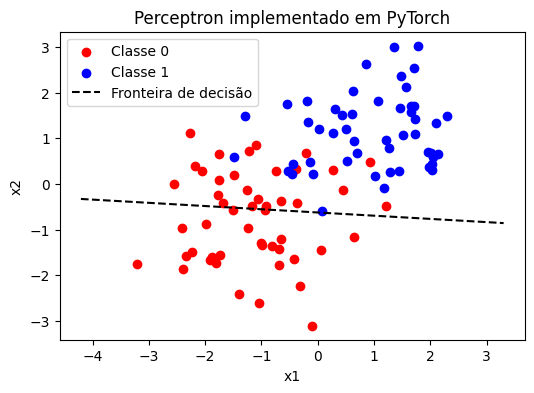

In [ ]:
# =========================================================
# define o modelo Perceptron
# =========================================================
import torch

class Perceptron(torch.nn.Module):
    def __init__(self, n_features):
        """
        Inicializa o Perceptron.
        Parâmetro
        ---------
        n_features : int
            Número de atributos de entrada.
        Exemplo: Se cada amostra possui dois atributos, como x1 e x2, então n_features = 2.
        """
        # Inicializa a classe base torch.nn.Module.
        # Isso é necessário para criar modelos no PyTorch.
        super().__init__()

        # Define uma camada linear.
        # Essa camada calcula:
        #     z = w1*x1 + w2*x2 + ... + wn*xn + b
        # onde:
        # - x1, x2, ..., xn são os atributos de entrada;
        # - w1, w2, ..., wn são os pesos aprendidos pelo modelo;
        # - b é o viés;
        # - z é a saída linear antes da ativação.
        # O segundo argumento é 1 porque queremos uma única saída.
        self.linear = torch.nn.Linear(n_features, 1)

    def forward(self, x):
        """
        Define como o dado de entrada passa pelo modelo.
        Parâmetro
        ---------
        x : torch.Tensor
            Tensor contendo os dados de entrada.
        Retorna
        -------
        torch.Tensor
            Classe prevista pelo Perceptron: 0 ou 1.
        """
        # Calcula a combinação linear dos atributos.
        #     z = w1*x1 + w2*x2 + ... + wn*xn + b
        z = self.linear(x)
        # Aplica a função degrau.
        # A regra de decisão é:
        #     se z >= 0, classifica como 1
        #     se z <  0, classifica como 0
        condicao = z >= 0

        # Criamos um tensor de saída com o mesmo formato de z.
        # Inicialmente, colocamos todas as previsões como 0.
        y_pred = torch.zeros_like(z)
        # Para os casos em que a condição é verdadeira, isto é, onde z >= 0, mudamos a previsão para 1.
        y_pred[condicao] = 1.0
        # Retornamos as classes previstas.
        return y_pred

# =========================================================
# inicia o modelo
# =========================================================
modelo = Perceptron(n_features=2)

# =========================================================
# treina o Perceptron manualmente
# =========================================================
taxa_aprendizado = 0.1
num_epocas = 20
for epoca in range(num_epocas):

    erros = 0

    for xi, yi in zip(X, y):

        # Ajustar dimensões
        xi = xi.reshape(1, -1)

        # Predição atual
        y_pred = modelo(xi).item()

        # Erro de classificação
        erro = yi.item() - y_pred

        # Atualização dos pesos apenas se houver erro
        if erro != 0:
            erros += 1

            with torch.no_grad():
                modelo.linear.weight += taxa_aprendizado * erro * xi
                modelo.linear.bias += taxa_aprendizado * erro

    print(f"Época {epoca + 1}: erros = {erros}")

# =========================================================
# mostra os parâmetros aprendidos
# =========================================================
w = modelo.linear.weight.detach().numpy()[0]
b = modelo.linear.bias.item()

print("\nPesos aprendidos:")
print("w1 =", w[0])
print("w2 =", w[1])
print("b  =", b)

# =========================================================
# visualiza os dados e a reta de decisão
# =========================================================
plt.figure(figsize=(6, 4))

plt.scatter(X0[:, 0], X0[:, 1],color = 'red', label="Classe 0")
plt.scatter(X1[:, 0], X1[:, 1], color = 'blue', label="Classe 1")

# Reta de decisão:
# w1*x1 + w2*x2 + b = 0
x_vals = torch.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)

# Isolando x2:
# x2 = -(w1*x1 + b)/w2
y_vals = -(w[0] * x_vals + b) / w[1]

plt.plot(x_vals, y_vals, '--k', label="Fronteira de decisão")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron implementado em PyTorch")
plt.legend()
plt.grid(False)
plt.show()

Podemos classificar os dados da flor íris usando o Perceptron:

In [ ]:
import torch
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================================================
# carrega os dados da Iris
# =========================================================
iris = load_iris()
X = iris.data
y = iris.target

# =========================================================
# separa os dados em treino e teste
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# =========================================================
# padroniza os dados
# =========================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================================
# converte para tensores PyTorch
# =========================================================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# =========================================================
# define o modelo Perceptron multiclasse
# =========================================================
class PerceptronMulticlasse(torch.nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        # Camada linear: recebe n_features atributos e produz n_classes saídas
        self.linear = torch.nn.Linear(n_features, n_classes)

    def forward(self, x):
        # Calcula as pontuações brutas de cada classe
        scores = self.linear(x)
        # Retorna a classe com maior pontuação
        return torch.argmax(scores, dim=1)

# =========================================================
# inicia o modelo
# =========================================================
modelo = PerceptronMulticlasse(n_features=4,n_classes=3)

# =========================================================
# treina o Perceptron manualmente
# =========================================================
taxa_aprendizado = 0.1
num_epocas = 50

for epoca in range(num_epocas):

    erros = 0

    for xi, yi in zip(X_train, y_train):

        # Ajusta a dimensão da entrada
        xi = xi.reshape(1, -1)

        # Predição atual
        y_pred = modelo(xi).item()

        # Atualiza os pesos apenas se houver erro
        if y_pred != yi.item():
            erros += 1

            with torch.no_grad():
                # Aumenta os pesos associados à classe correta
                modelo.linear.weight[yi] += taxa_aprendizado * xi.squeeze()
                modelo.linear.bias[yi] += taxa_aprendizado

                # Reduz os pesos associados à classe prevista incorretamente
                modelo.linear.weight[y_pred] -= taxa_aprendizado * xi.squeeze()
                modelo.linear.bias[y_pred] -= taxa_aprendizado

    #print(f"Época {epoca + 1}: erros = {erros}")

# =========================================================
# avaliação no conjunto de teste
# =========================================================
modelo.eval()
with torch.no_grad():
    y_pred_test = modelo(X_test)

acc = accuracy_score(y_test.numpy(), y_pred_test.numpy())

print("\nAcurácia no teste:", acc)

print("\nMatriz de confusão:")
print(confusion_matrix(y_test.numpy(), y_pred_test.numpy()))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_test.numpy(),
        y_pred_test.numpy(),
        target_names=iris.target_names
    )
)


Acurácia no teste: 0.9666666666666667

Matriz de confusão:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Relatório de classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Regressão linear usando PyTorch

No caso da regressão linear, podemos interpretá-la como uma rede neural composta por um único neurônio com função de ativação linear. Nesse caso, a saída do neurônio é dada diretamente por uma combinação linear das variáveis de entrada.

Para uma única variável de entrada, a estrutura matemática é dada por:
$
\hat{y} = wx + b.
$

Essa expressão é equivalente ao modelo clássico de regressão linear:
$
\hat{y} = \beta_1 x + \beta_0,
$

em que $\beta_1 = w$ e $\beta_0 = b$.

No caso da regressão linear multivariada, podemos interpretá-la como uma rede neural composta por uma única camada linear. Nesse caso, a saída é dada por uma combinação linear de várias variáveis de entrada.

Suponha que temos (p) variáveis explicativas:
$$
x_1, x_2, \ldots, x_p.
$$
A saída do modelo é dada por:
$$
\hat{y} = w_1x_1 + w_2x_2 + \cdots + w_px_p + b.
$$
Essa expressão pode ser escrita de forma vetorial como:
$$
\hat{y} = \mathbf{w}^\top \mathbf{x} + b,
$$
em que
$$
\mathbf{x} =
\begin{bmatrix}
x_1 \
x_2 \
\vdots \
x_p
\end{bmatrix},
\quad
\mathbf{w} =
\begin{bmatrix}
w_1 \
w_2 \
\vdots \
w_p
\end{bmatrix}.
$$
Portanto, essa rede é equivalente ao modelo clássico de regressão linear multivariada:
$$
\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p,
$$
em que $\beta_0 = b$ e $\beta_j = w_j$, para $j = 1, 2, \ldots, p$.

Assim, com uma única camada linear e sem função de ativação não linear, a rede neural representa um hiperplano no espaço das variáveis de entrada. Ela pode modelar relações lineares entre as variáveis explicativas e a variável resposta, mas não consegue representar relações não lineares complexas.

<img src="https://raw.githubusercontent.com/vicolab/neural-network-intro/79c2a16b37d9f1eb4b8861957f2f8f0de4d9a6d0/1-regression/resources/linear-regression-net.png" width=500 />

Época 500, perda = 0.560052
Época 1000, perda = 0.560000
Época 1500, perda = 0.560000
Época 2000, perda = 0.560000
Época 2500, perda = 0.560000
Época 3000, perda = 0.560000
Época 3500, perda = 0.560000
Época 4000, perda = 0.560000
Época 4500, perda = 0.560000
Época 5000, perda = 0.560000

Valores reais:
tensor([ 2.,  3.,  5.,  7., 11.])

Valores previstos:
tensor([ 1.2000,  3.4000,  5.6000,  7.8000, 10.0000])


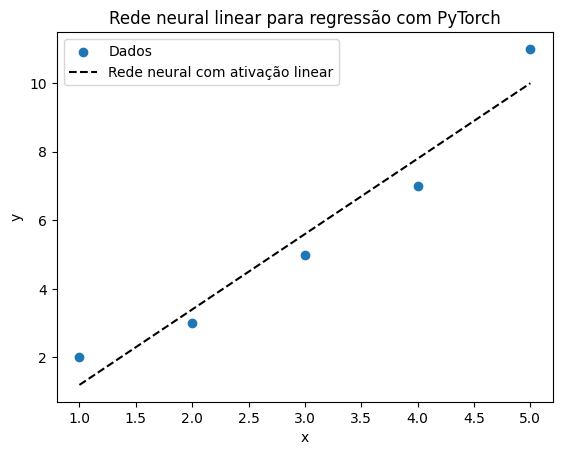

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------------
# Dados
# -----------------------------
x = torch.tensor([[1.0],
                  [2.0],
                  [3.0],
                  [4.0],
                  [5.0]])

y = torch.tensor([[2.0],
                  [3.0],
                  [5.0],
                  [7.0],
                  [11.0]])

# -----------------------------
# Rede neural com ativação linear e 1 neurônio na camada oculta
# -----------------------------
import torch
import torch.nn as nn

# Definimos uma rede neural para regressão.
# Ela recebe um valor de entrada x e produz uma estimativa y_hat.
class RedeNeuralRegressao(nn.Module):
    def __init__(self):
        # Inicializa a classe base nn.Module.
        # Toda rede neural definida em PyTorch deve herdar de nn.Module.
        super().__init__()

        # Primeira camada linear da rede.
        # nn.Linear(1, 1) significa:
        # - a camada recebe 1 variável de entrada;
        # - a camada produz 1 valor de saída.
        # Matematicamente, essa camada calcula: h = w1*x + b1
        self.camada_oculta = nn.Linear(1, 1)

        # Segunda camada linear da rede.
        # Ela recebe o valor h produzido pela primeira camada e gera a saída final y_hat.
        # Matematicamente: y_hat = w2*h + b2
        self.camada_saida = nn.Linear(1, 1)

    def forward(self, x):
        # Calcula a saída da primeira camada linear: h = w1*x + b1
        # Essa etapa é chamada de camada oculta, embora aqui ela tenha apenas um neurônio.
        h = self.camada_oculta(x)
        # Neste exemplo, não aplicamos uma função de ativação não linear, como ReLU, sigmoid ou tanh.
        # Portanto, a ativação é linear.
        # Isso significa que h é passado diretamente para a próxima camada.
        # Em outras palavras, a rede faz: y_hat = w2*h + b2
        y_hat = self.camada_saida(h)
        # Retorna a previsão final da rede.
        return y_hat

# -----------------------------
# Inicialização do modelo
# -----------------------------
modelo = RedeNeuralRegressao()

# -----------------------------
# Função de perda e otimizador
# -----------------------------
criterio = nn.MSELoss()
otimizador = torch.optim.SGD(modelo.parameters(), lr=0.01)
epochs = 5000

# -----------------------------
# Treinamento
# -----------------------------
for epoch in range(epochs):
    y_hat = modelo(x)
    loss = criterio(y_hat, y)
    otimizador.zero_grad()
    loss.backward()
    otimizador.step()
    if (epoch + 1) % 500 == 0:
        print(f"Época {epoch+1}, perda = {loss.item():.6f}")

# -----------------------------
# Resultado
# -----------------------------
with torch.no_grad():
    y_pred = modelo(x)

print("\nValores reais:")
print(y.squeeze())

print("\nValores previstos:")
print(y_pred.squeeze())

# -----------------------------
# Visualização
# -----------------------------
plt.scatter(x.numpy(), y.numpy(), label="Dados")
x_plot = torch.linspace(1, 5, 100).reshape(-1, 1)
with torch.no_grad():
    y_plot = modelo(x_plot)
plt.plot(x_plot.numpy(), y_plot.numpy(), '--k', label="Rede neural com ativação linear")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Rede neural linear para regressão com PyTorch")
plt.legend()
plt.grid(False)
plt.show()

Para um novo conjunto de dados artificiais:

Época 100, perda = 4.1397
Época 200, perda = 3.9581
Época 300, perda = 3.8910
Época 400, perda = 3.8662
Época 500, perda = 3.8570
Época 600, perda = 3.8536
Época 700, perda = 3.8523
Época 800, perda = 3.8519
Época 900, perda = 3.8517
Época 1000, perda = 3.8516

Modelo ajustado:
y = 1.9900x + 1.1665


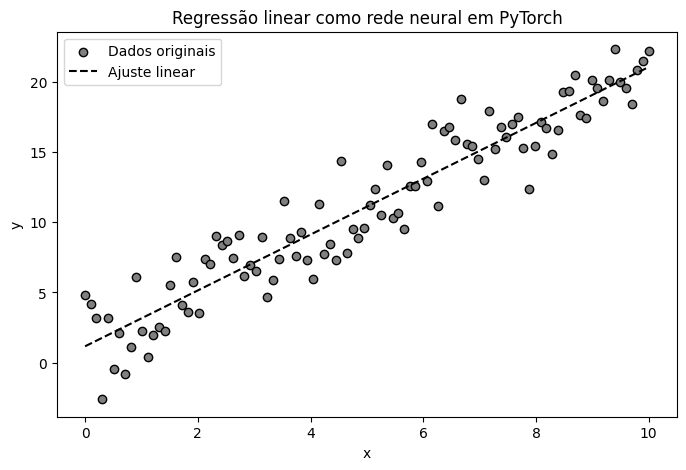

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =========================================================
# Gera os dados sintéticos
# =========================================================
torch.manual_seed(42)

# Dados de entrada
X = torch.linspace(0, 10, 100).reshape(-1, 1)

# Relação verdadeira: y = 2x + 1 + ruído
ruido = torch.randn(X.size()) * 2
y = 2 * X + 1 + ruido

# =========================================================
# Define o modelo: regressão linear como rede neural
# =========================================================
class RegressaoLinearNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Um único neurônio: entrada com 1 atributo e saída com 1 valor
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        # Ativação linear: a saída da camada linear é usada diretamente
        return self.linear(x)

# =========================================================
# Inicializa o modelo
# =========================================================
modelo = RegressaoLinearNN()

# =========================================================
# Define a função de perda e o otimizador
# =========================================================
criterio = nn.MSELoss()
otimizador = torch.optim.SGD(modelo.parameters(), lr=0.01)
epochs = 1000

# =========================================================
# Treinamento
# =========================================================
for epoch in range(epochs):
    # Predição do modelo
    y_pred = modelo(X)
    # Cálculo da perda
    loss = criterio(y_pred, y)
    # Zera os gradientes acumulados
    otimizador.zero_grad()
    # Calcula os gradientes
    loss.backward()
    # Atualiza os parâmetros
    otimizador.step()
    # Mostra a perda a cada 100 épocas
    if (epoch + 1) % 100 == 0:
        print(f"Época {epoch+1}, perda = {loss.item():.4f}")

# =========================================================
# Parâmetros ajustados
# =========================================================
peso = modelo.linear.weight.item()
bias = modelo.linear.bias.item()
print("\nModelo ajustado:")
print(f"y = {peso:.4f}x + {bias:.4f}")

# =========================================================
# Visualização
# =========================================================
with torch.no_grad():
    y_ajustado = modelo(X)

plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(),y.numpy(),color="gray",edgecolor="black",label="Dados originais")
plt.plot(X.numpy(),y_ajustado.numpy(),'--k',label="Ajuste linear")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão linear como rede neural em PyTorch")
plt.legend()
plt.grid(False)
plt.show()

## Multilayer perceptron (MLP)

Vamos implementar a rede neural a seguir:

* 10 neurônios de entrada;
* 1ª camada oculta com 6 neurônios;
* 2ª camada oculta com 4 neurônios;
* camada de saída com 3 neurônios;
* termos de bias em cada camada linear.

<img src="https://camo.githubusercontent.com/3eeaaaf993f765d2cfccc403b413c3415f15fef23a62b6c2dce349aceb401268/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f617070656e6469782d615f636f6d707265737365642f392e77656270
" width=500 />

In [ ]:
import torch
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        # Inicializa a classe base nn.Module.
        # Toda rede neural em PyTorch deve herdar de nn.Module.
        super().__init__()
        # nn.Sequential permite empilhar as camadas da rede na ordem em que os dados irão passar por elas.
        self.layers = nn.Sequential(
            # 1ª camada oculta
            # nn.Linear(10, 6) cria uma camada totalmente conectada.
            # Ela recebe um vetor com 10 variáveis de entrada: x = [x1, x2, ..., x10]
            # e produz 6 valores de saída, um para cada neurônio da primeira camada oculta.
            # Matematicamente: h1 = W1 x + b1
            nn.Linear(10, 6),
            # Função de ativação ReLU.
            nn.ReLU(),

            # 2ª camada oculta
            # Agora a entrada da camada tem tamanho 6, pois ela recebe as 6 saídas da camada anterior.
            # A saída terá tamanho 4, pois essa camada possui 4 neurônios.
            # Matematicamente: h2 = W2 h1 + b2
            nn.Linear(6, 4),
            # Segunda aplicação da função ReLU.
            nn.ReLU(),

            # Camada de saída
            # A camada de saída recebe os 4 valores produzidos pela camada oculta anterior e gera 3 valores finais.
            # Matematicamente: y_hat = W3 h2 + b3
            nn.Linear(4, 3)
        )

    def forward(self, x):
        # Define o fluxo dos dados pela rede.
        # A entrada x passa sequencialmente por:
        # Linear(10, 6) -> ReLU -> Linear(6, 4) -> ReLU -> Linear(4, 3)
        # O resultado final é retornado como saída da rede.
        return self.layers(x)


# Cria uma instância da rede neural.
modelo = NeuralNetwork()

# Exibe a arquitetura do modelo.
print(modelo)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=10, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=3, bias=True)
  )
)


Vamos usar essa ideia para classificar os dado da flor íris. Como a base Iris tem 4 atributos de entrada e 3 classes, teremos:
$4\rightarrow 30\rightarrow 20\rightarrow 3$.

Formato de X: (150, 4)
Formato de y: (150,)
Classes: ['setosa' 'versicolor' 'virginica']
NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)
Época 050 | Perda treino = 0.0469 | Acurácia treino = 0.9750 | Perda teste = 0.0658 | Acurácia teste = 0.9667
Época 100 | Perda treino = 0.0237 | Acurácia treino = 0.9833 | Perda teste = 0.1038 | Acurácia teste = 0.9667
Época 150 | Perda treino = 0.0116 | Acurácia treino = 1.0000 | Perda teste = 0.1195 | Acurácia teste = 0.9667
Época 200 | Perda treino = 0.0036 | Acurácia treino = 1.0000 | Perda teste = 0.1163 | Acurácia teste = 0.9667
Época 250 | Perda treino = 0.0015 | Acurácia treino = 1.0000 | Perda teste = 0.1137 | Acurácia teste = 0.9667
Época 300 | Perda treino = 0.0008 | Acurácia treino = 1.0000 | Perda teste = 0.1119 | Acurácia teste = 0.9

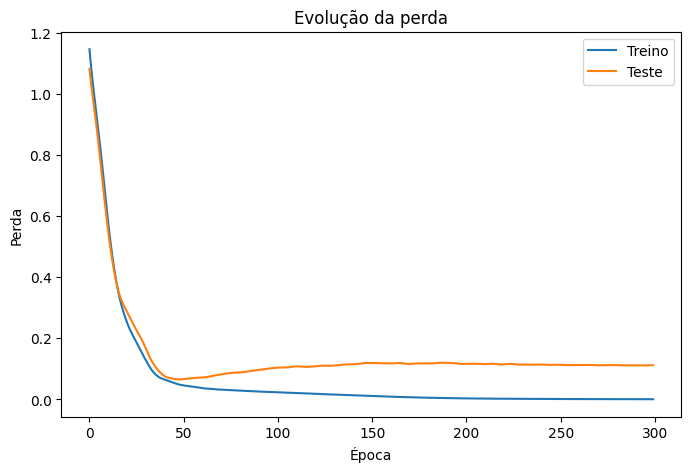

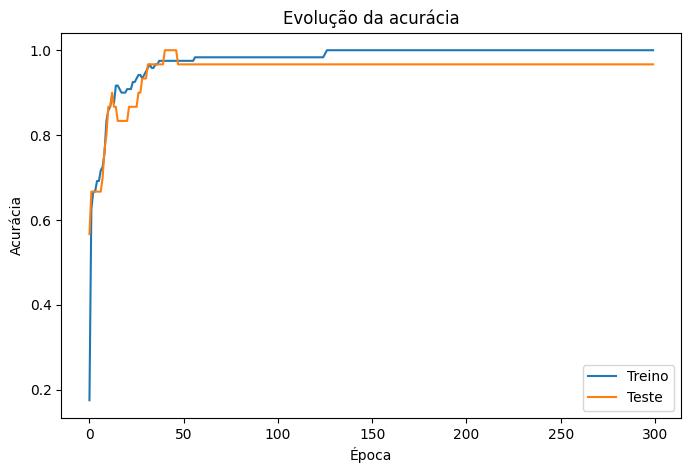

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================================================
# 1. Carregar os dados da Iris
# =========================================================
iris = load_iris()
X = iris.data
y = iris.target

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Classes:", iris.target_names)

# =========================================================
# 2. Separar dados em treino e teste
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# =========================================================
# 3. Padronizar os dados
# =========================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================================
# 4. Converter para tensores PyTorch
# =========================================================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# =========================================================
# 5. Definir a rede neural
# =========================================================
class NeuralNetwork(torch.nn.Module): # Define uma classe chamada NeuralNetwork.
    def __init__(self, num_inputs, num_outputs): # Método construtor da classe.
        # num_inputs: número de variáveis de entrada da rede.
        # No caso da base Iris, por exemplo, num_inputs = 4.
        # num_outputs: número de saídas da rede.
        # No caso da base Iris, como há 3 classes, num_outputs = 3.

        super().__init__()
        # Chama o construtor da classe mãe torch.nn.Module.
        # Isso é necessário para que o PyTorch registre corretamente as camadas e os parâmetros treináveis da rede.

        self.layers = torch.nn.Sequential(
            # Cria uma sequência de camadas. Os dados passam por essas camadas na ordem em que aparecem.

            # 1ª camada oculta
            torch.nn.Linear(num_inputs, 30),
            # Camada totalmente conectada, também chamada de camada linear.
            # Recebe num_inputs valores de entrada e produz 30 valores de saída, que correspondem aos 30 neurônios da primeira camada oculta.

            # Função de ativação ReLU.
            torch.nn.ReLU(),

            # 2ª camada oculta
            torch.nn.Linear(30, 20),
            # Segunda camada totalmente conectada.
            # Recebe os 30 valores produzidos pela camada anterior e produz 20 valores de saída.
            # Esses 20 valores correspondem aos 20 neurônios da segunda camada oculta.

            # Segunda aplicação da função de ativação ReLU.
            torch.nn.ReLU(),

            # camada de saída
            torch.nn.Linear(20, num_outputs),
            # Camada final da rede.
            # Recebe os 20 valores da segunda camada oculta e produz num_outputs valores.           #
            # Em classificação multiclasse, num_outputs é igual ao número de classes.
            # Por exemplo, para a base Iris, num_outputs = 3.
            # Esses valores de saída são chamados de logits. Eles ainda não são probabilidades.
        )

    def forward(self, x):
        # Define a propagação direta da rede.
        # Esse método especifica como a entrada x passa pelas camadas até produzir a saída final.
        # faz a entrada x passar por todas as camadas: x → Linear → ReLU → Linear → ReLU → Linear → logits

        logits = self.layers(x)
        # Aplica todas as camadas definidas em self.layers à entrada x.
        # A saída é chamada de logits porque, em problemas de classificação, esses valores representam as pontuações brutas de cada classe,
        # antes da aplicação de uma função softmax.

        return logits
        # Retorna os logits produzidos pela rede. Logits são as saídas brutas da rede neural antes de serem transformadas em probabilidades.
        # Para classificação multiclasse, normalmente usamos esses logits diretamente com torch.nn.CrossEntropyLoss(), pois essa função
        # aplica internamente o softmax de maneira numericamente estável.


# A base Iris tem 4 atributos de entrada e 3 classes
num_inputs = 4
num_outputs = 3

modelo = NeuralNetwork(num_inputs, num_outputs)
print(modelo)

# =========================================================
# 6. Definir função de perda e otimizador
# =========================================================
criterio = nn.CrossEntropyLoss()
# Define a função de perda usada no treinamento. Essa função é adequada para classificação multiclasse.
# O softmax é aplicado implicitamente dentro da CrossEntropyLoss, portanto devemos passar os logits diretamente, sem aplicar softmax antes.
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.01) # Define o otimizador usado para atualizar os pesos da rede neural.

# =========================================================
# 7. Treinamento
# =========================================================
epochs = 300
historico_loss_treino = []
historico_acc_treino = []
historico_loss_teste = []
historico_acc_teste = []
for epoch in range(epochs):
    # Coloca o modelo em modo de treinamento
    modelo.train()
    # Calcula as saídas da rede para os dados de treino
    logits_train = modelo(X_train) # # o PyTorch chama automaticamente: modelo.forward(X_train)
    # Calcula a perda no conjunto de treino
    loss_train = criterio(logits_train, y_train)
    # Zera os gradientes acumulados
    otimizador.zero_grad()
    # Calcula os gradientes por retropropagação
    loss_train.backward()
    # Atualiza os parâmetros da rede
    otimizador.step()
    # Calcula a acurácia no conjunto de treino
    # torch.no_grad() evita o cálculo de gradientes nessa etapa
    with torch.no_grad():
        y_pred_train = torch.argmax(logits_train, dim=1)
        acc_train = (y_pred_train == y_train).float().mean()

    # Coloca o modelo em modo de avaliação
    modelo.eval()

    # Avalia o modelo no conjunto de teste sem calcular gradientes
    with torch.no_grad():
        logits_test = modelo(X_test)
        loss_test = criterio(logits_test, y_test)

        y_pred_test = torch.argmax(logits_test, dim=1)
        acc_test = (y_pred_test == y_test).float().mean()

    # Armazena perda e acurácia ao longo das épocas
    historico_loss_treino.append(loss_train.item())
    historico_acc_treino.append(acc_train.item())

    historico_loss_teste.append(loss_test.item())
    historico_acc_teste.append(acc_test.item())

    # Imprime os resultados a cada 50 épocas
    if (epoch + 1) % 50 == 0:
        print(
            f"Época {epoch+1:03d} | "
            f"Perda treino = {loss_train.item():.4f} | "
            f"Acurácia treino = {acc_train.item():.4f} | "
            f"Perda teste = {loss_test.item():.4f} | "
            f"Acurácia teste = {acc_test.item():.4f}"
        )

# =========================================================
# 8. Avaliação final
# =========================================================
# Coloca o modelo em modo de avaliação
modelo.eval()

# Faz as predições finais no conjunto de teste
with torch.no_grad():
    logits_test = modelo(X_test)
    y_pred_test = torch.argmax(logits_test, dim=1)

# Calcula a acurácia final no conjunto de teste
acc_final = accuracy_score(y_test.numpy(), y_pred_test.numpy())

print("\nAcurácia final no teste:", acc_final)

# Mostra a matriz de confusão
print("\nMatriz de confusão:")
print(confusion_matrix(y_test.numpy(), y_pred_test.numpy()))

# Mostra métricas como precisão, revocação e F1-score
print("\nRelatório de classificação:")
print(
    classification_report(
        y_test.numpy(),
        y_pred_test.numpy(),
        target_names=iris.target_names
    )
)
# =========================================================
# 9. Gráfico da perda
# =========================================================
# Plota a evolução da perda no treino e no teste
plt.figure(figsize=(8, 5))
plt.plot(historico_loss_treino, label="Treino")
plt.plot(historico_loss_teste, label="Teste")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.title("Evolução da perda")
plt.legend()
plt.grid(False)
plt.show()

# =========================================================
# 10. Gráfico da acurácia
# =========================================================
# Plota a evolução da acurácia no treino e no teste
plt.figure(figsize=(8, 5))
plt.plot(historico_acc_treino, label="Treino")
plt.plot(historico_acc_teste, label="Teste")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Evolução da acurácia")
plt.legend()
plt.grid(False)
plt.show()

## Classificação de imagens

A base MNIST é uma das bases de dados mais clássicas em aprendizado de máquina e visão computacional. Ela é composta por imagens de dígitos manuscritos, de 000 a 999, sendo amplamente utilizada como exemplo introdutório em problemas de classificação de imagens.

Cada elemento da base corresponde a uma imagem de um dígito escrito à mão, associada ao seu respectivo rótulo, que indica qual algarismo está representado na imagem.

A base contém 60.000 imagens no conjunto de treinamento e 10.000 imagens no conjunto de teste. Cada imagem possui dimensão $28 \times 28$ pixels, totalizando 784 pixels por imagem. Como as imagens estão em tons de cinza, cada pixel pode ser representado por um único valor numérico, geralmente no intervalo de 0 a 255, ou, após normalização, no intervalo de 0 a 1.

A base possui 10 classes:

0,1,2,3,4,5,6,7,8,9.

Portanto, uma rede neural para classificar MNIST geralmente tem:

* 784 entradas, uma para cada pixel;
* uma ou mais camadas ocultas;
* 10 neurônios na saída, um para cada dígito.

Por exemplo: $784\rightarrow 128\rightarrow  64\rightarrow  10$

A saída da rede contém 10 valores, chamados de logits. O maior deles indica a classe prevista.

Vamos fazer a classificação da base usando uma rede neural.

Dispositivo usado: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 375kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.98MB/s]


NeuralNetwork(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)
Época 1/5 | Perda = 0.3328 | Acurácia = 0.9062
Época 2/5 | Perda = 0.1354 | Acurácia = 0.9596
Época 3/5 | Perda = 0.0945 | Acurácia = 0.9715
Época 4/5 | Perda = 0.0717 | Acurácia = 0.9777
Época 5/5 | Perda = 0.0558 | Acurácia = 0.9821

Acurácia no conjunto de teste: 0.9756


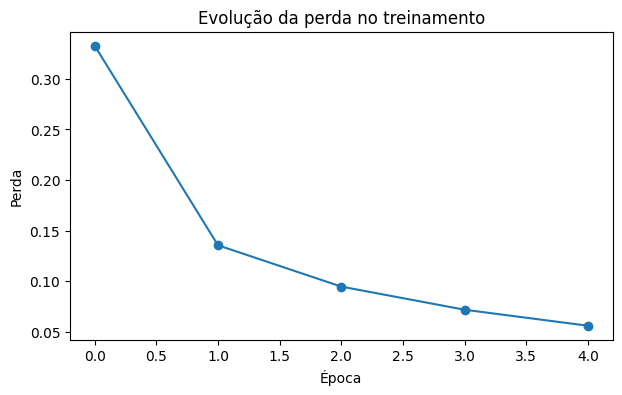

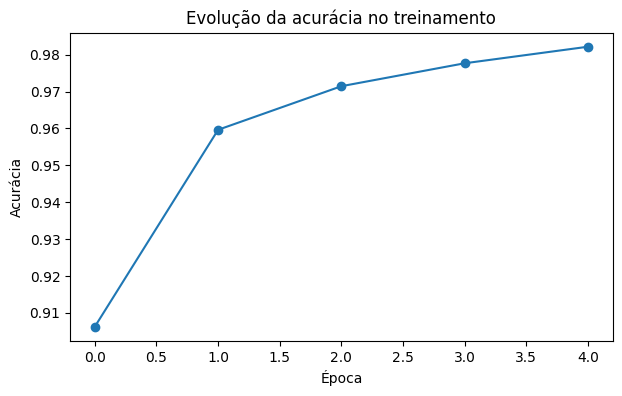

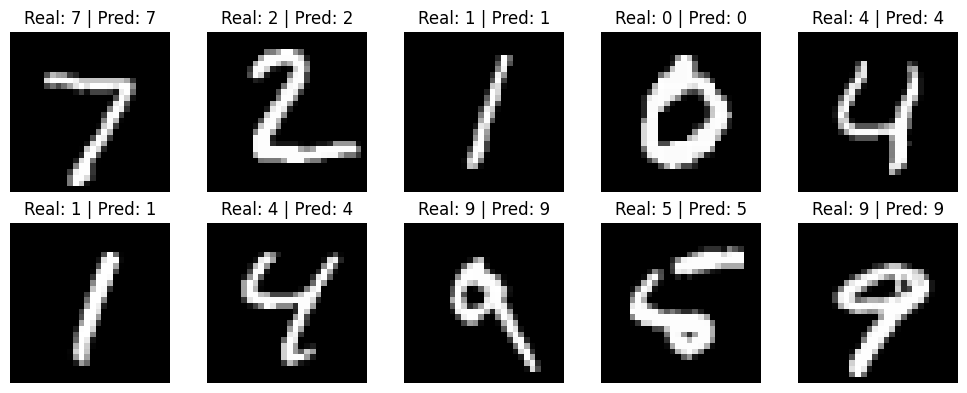

In [ ]:
#!pip install torchvision # se não estiver instalado, descomente
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# =========================================================
# 1. Configurações iniciais
# =========================================================
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo usado:", device)

# =========================================================
# 2. Transformação dos dados
# =========================================================
# ToTensor() converte a imagem para tensor e normaliza os pixels para o intervalo [0, 1].
transform = transforms.ToTensor()

# =========================================================
# 3. Carregar a base MNIST usando torchvision
# =========================================================
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# =========================================================
# 4. Criar os DataLoaders
# =========================================================
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# =========================================================
# 5. Definir a rede neural
# =========================================================
import torch
import torch.nn as nn

# =========================================================
# Rede neural para classificação de imagens 28 x 28
#
# Exemplo típico: MNIST
#
# Entrada:
# - imagem em tons de cinza com dimensão 1 x 28 x 28
#
# Saída:
# - 10 valores, um para cada dígito: 0, 1, 2, ..., 9
# =========================================================

class NeuralNetwork(nn.Module):
    def __init__(self):
        # Inicializa a classe base nn.Module.
        # Toda rede neural no PyTorch deve herdar dessa classe.
        super().__init__()

        # nn.Sequential organiza as operações da rede em sequência.
        # A entrada passa por cada camada na ordem em que elas aparecem.
        self.layers = nn.Sequential(
            # Transformação da imagem em vetor
            # A imagem original tem formato: 1 x 28 x 28
            # onde:
            # - 1 é o número de canais, pois a imagem está em escala de cinza;
            # - 28 é a altura;
            # - 28 é a largura.
            # A camada Flatten transforma a imagem em um vetor:
            # 1 x 28 x 28  ->  784
            # pois 28 * 28 = 784.
            nn.Flatten(),

            # 1ª camada linear
            # Recebe os 784 pixels da imagem como entrada e produz 128 valores.
            # Cada um desses 128 valores pode ser interpretado como a saída de um neurônio da primeira camada oculta.
            nn.Linear(28 * 28, 128),

            # Função de ativação ReLU.
            nn.ReLU(),

            # 2ª camada linear
            # Recebe os 128 valores da camada anterior e produz 64 novos valores.
            nn.Linear(128, 64),

            # Segunda função de ativação ReLU.
            nn.ReLU(),

            # Camada de saída
            # Recebe os 64 valores da camada anterior e produz 10 saídas.
            # Cada saída está associada a uma classe:
            # saída 0 -> dígito 0
            # saída 1 -> dígito 1
            # saída 2 -> dígito 2
            # ...
            # saída 9 -> dígito 9
            # Esses valores finais são chamados de logits.
            nn.Linear(64, 10)
        )

    def forward(self, x):
        # Define como os dados passam pela rede.
        # A entrada x passa por:
        # Flatten -> Linear(784, 128) -> ReLU
        #         -> Linear(128, 64)  -> ReLU
        #         -> Linear(64, 10)
        # O resultado final são os logits.
        logits = self.layers(x)

        # Retorna os logits.
        # Observação:
        # Não aplicamos softmax aqui porque, em PyTorch,
        # a função de perda nn.CrossEntropyLoss já aplica
        # internamente a operação apropriada aos logits.
        return logits


# Cria o modelo e envia seus parâmetros para o dispositivo escolhido.
# device pode ser, por exemplo:
# device = "cuda"  # GPU
device = "cpu"   # CPU
modelo = NeuralNetwork().to(device)

# Exibe a arquitetura da rede.
print(modelo)

# =========================================================
# 6. Função de perda e otimizador
# =========================================================
criterio = nn.CrossEntropyLoss()
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)

# =========================================================
# 7. Treinamento
# =========================================================
epochs = 5

historico_loss = []
historico_acc = []

for epoch in range(epochs):

    modelo.train()

    perda_total = 0
    corretos = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Predição
        logits = modelo(X_batch)

        # Perda
        loss = criterio(logits, y_batch)

        # Zera gradientes
        otimizador.zero_grad()

        # Calcula gradientes
        loss.backward()

        # Atualiza pesos
        otimizador.step()

        # Acumula a perda
        perda_total += loss.item()

        # Calcula acertos
        y_pred = torch.argmax(logits, dim=1)
        corretos += (y_pred == y_batch).sum().item()
        total += y_batch.size(0)

    perda_media = perda_total / len(train_loader)
    acuracia = corretos / total

    historico_loss.append(perda_media)
    historico_acc.append(acuracia)

    print(
        f"Época {epoch+1}/{epochs} | "
        f"Perda = {perda_media:.4f} | "
        f"Acurácia = {acuracia:.4f}"
    )

# =========================================================
# 8. Avaliação no conjunto de teste
# =========================================================
modelo.eval()

corretos = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = modelo(X_batch)
        y_pred = torch.argmax(logits, dim=1)

        corretos += (y_pred == y_batch).sum().item()
        total += y_batch.size(0)

acuracia_teste = corretos / total

print("\nAcurácia no conjunto de teste:", acuracia_teste)

# =========================================================
# 9. Gráfico da perda
# =========================================================

plt.figure(figsize=(7, 4))
plt.plot(historico_loss, marker="o")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.title("Evolução da perda no treinamento")
plt.grid(False)
plt.show()

# =========================================================
# 10. Gráfico da acurácia
# =========================================================

plt.figure(figsize=(7, 4))
plt.plot(historico_acc, marker="o")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Evolução da acurácia no treinamento")
plt.grid(False)
plt.show()

# =========================================================
# 11. Visualizar algumas predições
# =========================================================

modelo.eval()

X_batch, y_batch = next(iter(test_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    logits = modelo(X_batch)
    y_pred = torch.argmax(logits, dim=1)

# Voltar para CPU para visualização
X_batch = X_batch.cpu()
y_batch = y_batch.cpu()
y_pred = y_pred.cpu()

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_batch[i].squeeze(), cmap="gray")
    plt.title(f"Real: {y_batch[i].item()} | Pred: {y_pred[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Exercícios

1 - Classificação da base Fashion-MNIST usando o PyTorch.

Neste exercício, você deverá construir e avaliar modelos de aprendizado de máquina para classificar imagens da base Fashion-MNIST.

A base Fashion-MNIST é composta por imagens em escala de cinza de peças de vestuário, com dimensão ($28 \times 28$) pixels. Cada imagem pertence a uma entre 10 classes, como camiseta, calça, pulôver, vestido, casaco, sandália, camisa, tênis, bolsa e bota.

Utilizando Python e uma biblioteca de aprendizado profundo, como PyTorch, realize as seguintes etapas:

* a) Carregue a base Fashion-MNIST e separe os dados em conjuntos de treinamento e teste.
* b) Visualize algumas imagens da base, indicando suas respectivas classes.
* c) Faça o pré-processamento necessário dos dados, incluindo a normalização dos valores dos pixels.
* d) Implemente uma rede neural para classificar as imagens.
* e) Treine o modelo utilizando uma função de perda adequada para classificação multiclasse.
* f) Avalie o desempenho do modelo no conjunto de teste, calculando métricas como acurácia e matriz de confusão.
* g) Analise os resultados obtidos. Quais classes foram classificadas com maior facilidade? Quais apresentaram mais erros? Discuta possíveis razões para esses resultados.
* h) Investigue como alterações na arquitetura da rede, como número de camadas, número de neurônios e função de ativação, afetam o desempenho do classificador.

Use o código abaixo para baixar a base.

In [3]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor

# =========================================================
# Baixando a base Fashion-MNIST
# =========================================================
# A base Fashion-MNIST contém imagens em escala de cinza com dimensão 28 x 28 pixels.
# Cada imagem pertence a uma entre 10 classes de roupas e acessórios.
# =========================================================

# Conjunto de treinamento
train_data = datasets.FashionMNIST(
    root="data",          # pasta onde os dados serão salvos
    train=True,           # indica que queremos o conjunto de treinamento
    download=True,        # baixa a base caso ela ainda não exista
    transform=ToTensor()  # converte a imagem para tensor PyTorch
)

# Conjunto de teste
test_data = datasets.FashionMNIST(
    root="data",          # mesma pasta usada para salvar os dados
    train=False,          # indica que queremos o conjunto de teste
    download=True,        # baixa a base caso ela ainda não exista
    transform=ToTensor()  # converte a imagem para tensor PyTorch
)

print("Número de imagens de treinamento:", len(train_data))
print("Número de imagens de teste:", len(test_data))

ModuleNotFoundError: No module named 'torchvision'

### b) Visualização de imagens


In [ ]:
import matplotlib.pyplot as plt

class_names = [
    "Camiseta", "Calça", "Pulôver", "Vestido", "Casaco",
    "Sandália", "Camisa", "Tênis", "Bolsa", "Bota"
]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"{class_names[label]} ({label})")
    ax.axis("off")
plt.suptitle("Exemplos do conjunto de treinamento")
plt.tight_layout()
plt.show()


### c) Pré-processamento e normalização


In [ ]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ToTensor() converte pixels para [0, 1].
# Normalize() centraliza e escala usando média e desvio padrão da Fashion-MNIST.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_data_norm = datasets.FashionMNIST(root="data", train=True, download=False, transform=transform)
test_data_norm = datasets.FashionMNIST(root="data", train=False, download=False, transform=transform)

batch_size = 64
train_loader = DataLoader(train_data_norm, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data_norm, batch_size=batch_size, shuffle=False)

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo usado:", device)


### d) Rede neural


In [ ]:
import torch.nn as nn

class FashionNet(nn.Module):
    def __init__(self, hidden1=128, hidden2=64, activation=nn.ReLU):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden1),
            activation(),
            nn.Linear(hidden1, hidden2),
            activation(),
            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        return self.layers(x)


def treinar_e_avaliar(modelo, epochs=5, lr=0.001):
    from sklearn.metrics import accuracy_score

    criterio = nn.CrossEntropyLoss()
    otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)

    historico_loss = []
    historico_acc = []

    for epoch in range(epochs):
        modelo.train()
        perda_total = 0
        corretos = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = modelo(X_batch)
            loss = criterio(logits, y_batch)

            otimizador.zero_grad()
            loss.backward()
            otimizador.step()

            perda_total += loss.item()
            y_pred = torch.argmax(logits, dim=1)
            corretos += (y_pred == y_batch).sum().item()
            total += y_batch.size(0)

        perda_media = perda_total / len(train_loader)
        acuracia = corretos / total
        historico_loss.append(perda_media)
        historico_acc.append(acuracia)

        print(
            f"Época {epoch+1}/{epochs} | "
            f"Perda = {perda_media:.4f} | "
            f"Acurácia = {acuracia:.4f}"
        )

    modelo.eval()
    y_true, y_pred_all = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            logits = modelo(X_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            y_pred_all.extend(preds)
            y_true.extend(y_batch.numpy())

    acc_teste = accuracy_score(y_true, y_pred_all)
    return acc_teste, historico_loss, historico_acc, np.array(y_true), np.array(y_pred_all)


### e) Treinamento


In [ ]:
modelo = FashionNet().to(device)
print(modelo)

acc_teste, historico_loss, historico_acc, y_true, y_pred = treinar_e_avaliar(modelo, epochs=5)


### f) Avaliação no conjunto de teste


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(f"Acurácia no conjunto de teste: {acc_teste:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("\nMatriz de confusão:")
print(cm)

print("\nRelatório de classificação:")
print(classification_report(y_true, y_pred, target_names=class_names))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predição")
ax.set_ylabel("Classe real")
ax.set_title("Matriz de confusão - Fashion-MNIST")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(historico_loss, marker="o")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.title("Evolução da perda no treinamento")
plt.grid(False)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(historico_acc, marker="o")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Evolução da acurácia no treinamento")
plt.grid(False)
plt.show()


### g) Análise por classe


In [ ]:
acuracia_por_classe = cm.diagonal() / cm.sum(axis=1)
print("Acurácia por classe:")
for nome, acc in zip(class_names, acuracia_por_classe):
    print(f"  {nome:10s}: {acc:.4f}")

melhor = class_names[np.argmax(acuracia_por_classe)]
pior = class_names[np.argmin(acuracia_por_classe)]
print(f"\nClasse com maior facilidade: {melhor}")
print(f"Classe com mais dificuldade: {pior}")

erros = cm.copy()
np.fill_diagonal(erros, 0)
i, j = np.unravel_index(np.argmax(erros), erros.shape)
print(f"Erro mais comum: {class_names[i]} confundido com {class_names[j]} ({erros[i, j]} vezes)")


### g) Análise dos resultados

**Classes mais fáceis:** geralmente *Tênis*, *Sandália*, *Bolsa* e *Calça* tendem a ter acurácia mais alta, pois possuem formas e texturas distintas das demais peças de vestuário.

**Classes com mais erros:** *Camiseta*, *Camisa* e *Pulôver* costumam ser as mais confundidas entre si, pois são peças de tronco superior com silhueta e textura visualmente semelhantes em imagens $28 \times 28$ em escala de cinza.

**Possíveis razões:**
- Baixa resolução das imagens dificulta capturar detalhes finos (golas, mangas, botões).
- Classes semanticamente próximas compartilham padrões visuais parecidos.
- A rede totalmente conectada (MLP) não explora a estrutura espacial local das imagens, ao contrário de redes convolucionais.

**h) Alterações na arquitetura:** redes com mais neurônios tendem a aprender padrões mais complexos, mas podem exigir mais épocas ou regularização. Redes menores treinam mais rápido, porém com capacidade limitada. A função Tanh pode convergir de forma diferente da ReLU; em geral, ReLU é mais estável para redes profundas. Uma única camada oculta reduz a capacidade de representação e costuma diminuir a acurácia.

### h) Comparação de arquiteturas


In [ ]:
configuracoes = [
    {"nome": "Base (128-64, ReLU)", "hidden1": 128, "hidden2": 64, "activation": nn.ReLU},
    {"nome": "Menos neurônios (64-32, ReLU)", "hidden1": 64, "hidden2": 32, "activation": nn.ReLU},
    {"nome": "Mais neurônios (256-128, ReLU)", "hidden1": 256, "hidden2": 128, "activation": nn.ReLU},
    {"nome": "Uma camada oculta (128, ReLU)", "hidden1": 128, "hidden2": 0, "activation": nn.ReLU},
    {"nome": "Base com Tanh", "hidden1": 128, "hidden2": 64, "activation": nn.Tanh},
]

resultados = []
for cfg in configuracoes:
    print(f"\n--- {cfg['nome']} ---")
    torch.manual_seed(42)

    if cfg["hidden2"] == 0:
        class FashionNet1Camada(nn.Module):
            def __init__(self, hidden1, activation):
                super().__init__()
                self.layers = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(28 * 28, hidden1),
                    activation(),
                    nn.Linear(hidden1, 10)
                )

            def forward(self, x):
                return self.layers(x)

        m = FashionNet1Camada(cfg["hidden1"], cfg["activation"]).to(device)
    else:
        m = FashionNet(cfg["hidden1"], cfg["hidden2"], cfg["activation"]).to(device)

    acc, _, _, _, _ = treinar_e_avaliar(m, epochs=5)
    resultados.append({"config": cfg["nome"], "acuracia": acc})

print("\n=== Comparação de arquiteturas ===")
for r in sorted(resultados, key=lambda x: x["acuracia"], reverse=True):
    print(f"{r['config']:35s} -> Acurácia teste: {r['acuracia']:.4f}")

nomes = [r["config"] for r in resultados]
accs = [r["acuracia"] for r in resultados]

plt.figure(figsize=(10, 5))
plt.barh(nomes, accs, color="steelblue")
plt.xlabel("Acurácia no teste")
plt.title("Impacto da arquitetura no desempenho")
plt.xlim(min(accs) - 0.02, max(accs) + 0.02)
plt.tight_layout()
plt.show()
